In [9]:
import sympy as sy

$$
\begin{array}{l}
\gamma_0=\alpha_0^{-\eta_0}-\beta_0^{-\eta0}
\\
g_0(t)=
\begin{cases}
0\ for\ 0\le t\le\alpha_0 \\
\frac{\eta_0}{\gamma_0t^{\eta0+1}}\ for\ \alpha_0\lt t\lt\beta0 \\
0\ for\ t\ge\beta0 \\
\end{cases}
\end{array}
$$

In [10]:
t, alpha0, beta0, eta0, alpha1, eta1, x = sy.symbols('t alpha0 beta0 eta0 alpha1 eta1 x')
gamma0 = alpha0**(-eta0) - beta0**(-eta0)
g0_pdf = eta0 / (gamma0 * t**(eta0 + 1))
g0_cdf = sy.integrate(g0_pdf, (t, alpha0, t))
print('CDF:')
display(g0_cdf)

CDF:


Piecewise((-1/(t**eta0*(-1/beta0**eta0 + alpha0**(-eta0))) + 1/(alpha0**eta0*(-1/beta0**eta0 + alpha0**(-eta0))), (eta0 > -oo) & (eta0 < oo) & Ne(eta0, 0)), (-eta0*log(alpha0)/(-1/beta0**eta0 + alpha0**(-eta0)) + eta0*log(t)/(-1/beta0**eta0 + alpha0**(-eta0)), True))

In [11]:
g0_inverse_cdf = sy.solve(sy.Eq(g0_cdf, x), t)
print('ICDF')
display(g0_inverse_cdf[1])

ICDF


Piecewise(((alpha0**eta0*beta0**eta0/(alpha0**eta0*x - beta0**eta0*x + beta0**eta0))**(1/eta0), (eta0 > -oo) & (eta0 < oo) & Ne(eta0, 0)), (nan, True))

$$
\begin{array}{l}
\gamma_1=\alpha_1^{-\eta_1} \\
g_1(t)=
\begin{cases}
0\ for\ 0\le t\le\alpha_1 \\
\frac{\eta_1}{\gamma_1t^{\eta_1+1}}\ for\ \alpha_1\lt t
\end{cases}
\end{array}
$$

In [12]:
gamma1 = alpha1**(-eta1)
g1_pdf = eta1 / (gamma1 * t**(eta1 + 1))
g1_cdf = sy.integrate(g1_pdf, (t, alpha1, t))
print('CDF:')
display(g1_cdf)

CDF:


Piecewise((-alpha1**eta1/t**eta1 + 1, (eta1 > -oo) & (eta1 < oo) & Ne(eta1, 0)), (-alpha1**eta1*eta1*log(alpha1) + alpha1**eta1*eta1*log(t), True))

In [13]:
g1_inverse_cdf = sy.solve(sy.Eq(g1_cdf, x), t)
print('ICDF:')
display(g1_inverse_cdf[1])

ICDF:


Piecewise(((-alpha1**eta1/(x - 1))**(1/eta1), (eta1 > -oo) & (eta1 < oo) & Ne(eta1, 0)), (nan, True))

# 1 Probability distribution

In [14]:
import matplotlib.pyplot as plt
import randomData

interarrival_list = list()
time0_list = list()
time1_list = list()
group_list = list()
rd = randomData.RandomData(1000, 0.7, 1.2, 3.6, 2.1, 2.8, 4.1, 0.9, 0.91, 1.27)
for i in range(10000):
    interarrival, time, group = rd.generate_service()
    interarrival_list.append(interarrival)
    group_list.append(group)
    if group == 0:
        time0_list.append(time)
    else:
        time1_list.append(time)

## 1.1	The probability distribution of inter-arrival time

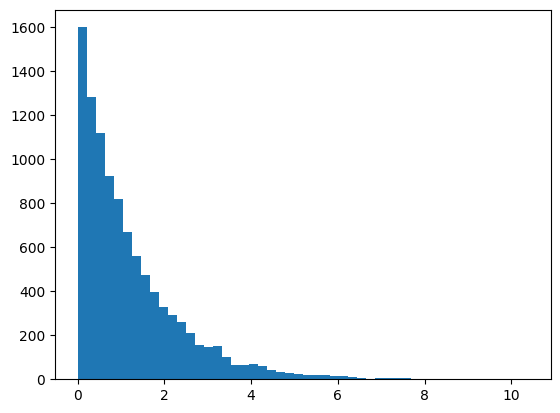

In [15]:
plt.hist(interarrival_list, 50)
plt.show()

## 1.2	The probability of service group

In [16]:
count = 0
for group in group_list:
    if group == 0:
        count += 1
print('group 0 / (group 0 + group 1) = ', count / len(group_list))

group 0 / (group 0 + group 1) =  0.6967


## 1.3	The probability distribution of service time

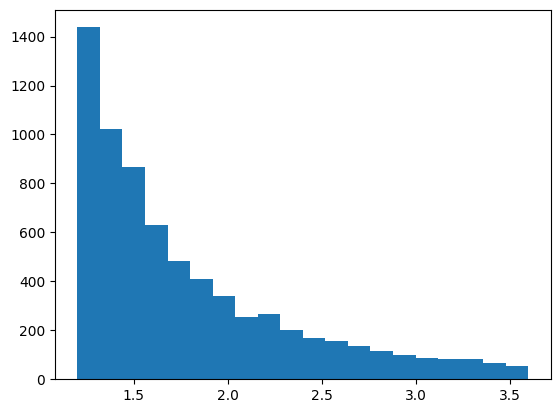

In [17]:
plt.hist(time0_list, 20)
plt.show()

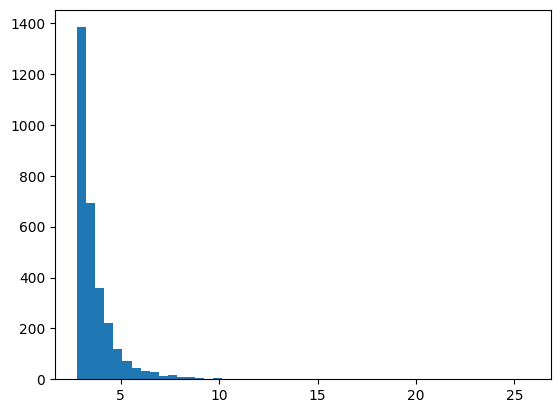

In [18]:
plt.hist(time1_list, 50)
plt.show()

# 2	Verifying the correctness of the simulation program

In [19]:
!sh ./run_test.sh 0
!sh ./run_test.sh 1
!sh ./run_test.sh 2
!sh ./run_test.sh 3
!sh ./run_test.sh 4
!sh ./run_test.sh 5
!sh ./run_test.sh 6

!python3 ./cf_output_with_ref.py 0
!python3 ./cf_output_with_ref.py 1
!python3 ./cf_output_with_ref.py 2
!python3 ./cf_output_with_ref.py 3
!python3 ./cf_output_with_ref.py 4
!python3 ./cf_output_with_ref.py 5
!python3 ./cf_output_with_ref.py 6

Test 0: Mean response time matches the reference
Test 0: Departure times match the reference
Test 1: Mean response time matches the reference
Test 1: Departure times match the reference
Test 2: Mean response time matches the reference
Test 2: Departure times match the reference
Test 3: Mean response time matches the reference
Test 3: Departure times match the reference
Test 4: Mean response time is within tolerance
Test 4: Mean response time is within tolerance
Test 5: Mean response time is within tolerance
Test 5: Mean response time is within tolerance
Test 6: Mean response time is within tolerance
Test 6: Mean response time is within tolerance


# 3	Simulation reproducible

In [20]:
import os
import subprocess

mrt0_list = list()
mrt1_list = list()

mrt_path = os.path.join('output', 'mrt_4.txt')
for i in range(100):
    subprocess.run(['sh', 'run_test.sh', '4'])
    with open(mrt_path, 'r') as f:
        mrt0, mrt1 = [float(mrt) for mrt in f.readline().strip().split()]
        mrt0_list.append(mrt0)
        mrt1_list.append(mrt1)

print('mrt0 list: ', mrt0_list)
print('mrt1 list: ', mrt1_list)

mrt0 list:  [2.0112, 2.0112, 2.0112, 2.0112, 2.0112, 2.0112, 2.0112, 2.0112, 2.0112, 2.0112, 2.0112, 2.0112, 2.0112, 2.0112, 2.0112, 2.0112, 2.0112, 2.0112, 2.0112, 2.0112, 2.0112, 2.0112, 2.0112, 2.0112, 2.0112, 2.0112, 2.0112, 2.0112, 2.0112, 2.0112, 2.0112, 2.0112, 2.0112, 2.0112, 2.0112, 2.0112, 2.0112, 2.0112, 2.0112, 2.0112, 2.0112, 2.0112, 2.0112, 2.0112, 2.0112, 2.0112, 2.0112, 2.0112, 2.0112, 2.0112, 2.0112, 2.0112, 2.0112, 2.0112, 2.0112, 2.0112, 2.0112, 2.0112, 2.0112, 2.0112, 2.0112, 2.0112, 2.0112, 2.0112, 2.0112, 2.0112, 2.0112, 2.0112, 2.0112, 2.0112, 2.0112, 2.0112, 2.0112, 2.0112, 2.0112, 2.0112, 2.0112, 2.0112, 2.0112, 2.0112, 2.0112, 2.0112, 2.0112, 2.0112, 2.0112, 2.0112, 2.0112, 2.0112, 2.0112, 2.0112, 2.0112, 2.0112, 2.0112, 2.0112, 2.0112, 2.0112, 2.0112, 2.0112, 2.0112, 2.0112]
mrt1 list:  [3.7427, 3.7427, 3.7427, 3.7427, 3.7427, 3.7427, 3.7427, 3.7427, 3.7427, 3.7427, 3.7427, 3.7427, 3.7427, 3.7427, 3.7427, 3.7427, 3.7427, 3.7427, 3.7427, 3.7427, 3.7427, 3.7427

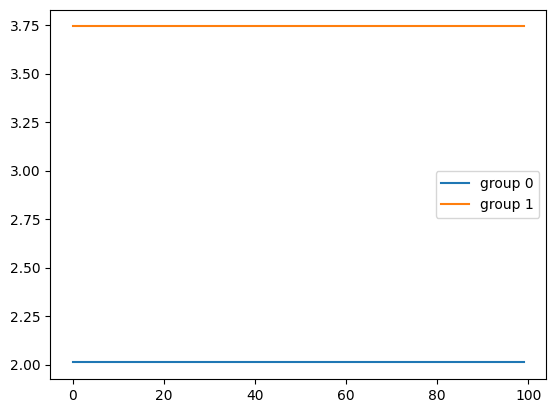

In [21]:
x = range(len(mrt0_list))

plt.plot(x, mrt0_list, label='group 0')
plt.plot(x, mrt1_list, label='group 1')
plt.legend()
plt.show()

# 4 Determine a suitable value of $n_0$

## 4.1 Running the simulation once and present the results

In [26]:
import os

def modify_line(filename, line, s):
    with open(filename, 'r') as f:
        lines = f.readlines()
    lines[line] = '{}\n'.format(s)
    with open(filename, 'w') as f:
        f.writelines(lines)

para_path = os.path.join('config', 'para_test.txt')
def modify_time_end(t):
    modify_line(para_path, 3, t)

def modify_n0(n0):
    modify_line(para_path, 1, n0)

def modify_seed(s):
    modify_line('seed.py', 0, 'seed = {}'.format(s))

def read_response_time():
    with open('response_time_group0_test.txt', 'r') as f:
        rt0_list = [float(line.strip().split()[0]) for line in f]
    with open('response_time_group1_test.txt', 'r') as f:
        rt1_list = [float(line.strip().split()[0]) for line in f]
    return (rt0_list, rt1_list)
    
modify_time_end(10000)
modify_n0(5)
modify_seed(1000)

In [24]:
!sh ./run_test.sh test

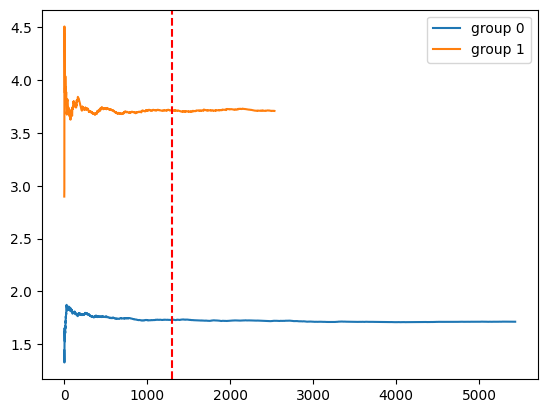

In [27]:
rt0_list, rt1_list = read_response_time()
x0 = range(1, len(rt0_list) + 1)
y0 = list()
for i in range(len(rt0_list)):
    y0.append(sum(rt0_list[0:i+1]) / (i + 1))

x1 = range(1, len(rt1_list) + 1)
y1 = list()
for i in range(len(rt1_list)):
    y1.append(sum(rt1_list[0:i+1]) / (i + 1))

plt.plot(x0, y0, label='group 0')
plt.plot(x1, y1, label='group 1')
plt.axvline(1300, color='r', linestyle='--')
plt.legend()
plt.show()

In [28]:
def mean(data):
    return sum(data) / len(data)

In [31]:
print('mrt0={:.4f}, mrt1={:.4f}'.format(mean(rt0_list), mean(rt1_list)))
print('mrt0={:.4f}, mrt1={:.4f}'.format(mean(rt0_list[1300:]), mean(rt1_list[1300:])))

mrt0=1.7131, mrt1=3.7074
mrt0=1.7073, mrt1=3.7029


In [44]:
start = 1300
sampling_frequency = 20
n = 10
time_end = 10000

In [33]:
def sample_standard_deviation(x, mean_value):
    S = 0
    for i in range(len(x)):
        S += (mean_value - x[i])**2
        return ( S / ( len(x) - 1 ) )**0.5

In [34]:
def confidence_interval(ssd, m):
    lower_value = '{:.4f}'.format(m - 2 * ssd /  sampling_frequency**0.5)
    upper_value = '{:.4f}'.format(m + 2 * ssd /  sampling_frequency**0.5)
    return (lower_value, upper_value)

In [42]:
import subprocess

modify_time_end(time_end)
for n0 in range(1, n):
    modify_n0(n0)
    with open('n0_{}.wmrt.txt'.format(n0), 'w') as wmrt:
        for seed in range(1001, 1021):
            print('n0={}, seed={}'.format(n0, seed))
            rt0_list = []
            rt1_list = []
            t0_list = []
            t1_list = []
            modify_seed(seed)
            subprocess.run('sh ./run_test.sh test', shell=True)
            with open('response_time_group0_test.txt', 'r') as f:
                for line in f:
                    rt, t = line.strip().split()
                    rt0_list.append(float(rt))
                    t0_list.append(float(t))
            with open ('response_time_group1_test.txt', 'r') as f:
                for line in f:
                    rt, t = line.strip().split()
                    rt1_list.append(float(rt))
                    t1_list.append(float(t))
            rt0_list = rt0_list[start:]
            rt1_list = rt1_list[start:]
            t0_list = t0_list[start:]
            t1_list = t1_list[start:]
            group0_percent = len(rt0_list) / (len(rt0_list) + len(rt1_list))
            grouup1_percent = 1 - group0_percent
            w0 = group0_percent / mean(t0_list)
            w1 = grouup1_percent / mean(t1_list)
            wmrt.write('{}\n'.format(mean(rt0_list) * w0 + mean(rt1_list) * w1))

n0=1, seed=1001
n0=1, seed=1002
n0=1, seed=1003
n0=1, seed=1004
n0=1, seed=1005
n0=1, seed=1006
n0=1, seed=1007
n0=1, seed=1008
n0=1, seed=1009
n0=1, seed=1010
n0=1, seed=1011
n0=1, seed=1012
n0=1, seed=1013
n0=1, seed=1014
n0=1, seed=1015
n0=1, seed=1016
n0=1, seed=1017
n0=1, seed=1018
n0=1, seed=1019
n0=1, seed=1020
n0=2, seed=1001
n0=2, seed=1002
n0=2, seed=1003
n0=2, seed=1004
n0=2, seed=1005
n0=2, seed=1006
n0=2, seed=1007
n0=2, seed=1008
n0=2, seed=1009
n0=2, seed=1010
n0=2, seed=1011
n0=2, seed=1012
n0=2, seed=1013
n0=2, seed=1014
n0=2, seed=1015
n0=2, seed=1016
n0=2, seed=1017
n0=2, seed=1018
n0=2, seed=1019
n0=2, seed=1020
n0=3, seed=1001
n0=3, seed=1002
n0=3, seed=1003
n0=3, seed=1004
n0=3, seed=1005
n0=3, seed=1006
n0=3, seed=1007
n0=3, seed=1008
n0=3, seed=1009
n0=3, seed=1010
n0=3, seed=1011
n0=3, seed=1012
n0=3, seed=1013
n0=3, seed=1014
n0=3, seed=1015
n0=3, seed=1016
n0=3, seed=1017
n0=3, seed=1018
n0=3, seed=1019
n0=3, seed=1020
n0=4, seed=1001
n0=4, seed=1002
n0=4, se

In [ ]:
print('-' * 50)
print('n0\t|\tconfidence interval')
for n0 in range(1, n):
    wmrt_list = []
    with open('n0_{}.wmrt.txt'.format(n0), 'r') as f:
        wmrt_list = [float(wmrt_value.strip()) for wmrt_value in f]
    mwrt = mean(wmrt_list)
    ssd = sample_standard_deviation(wmrt_list, mwrt)
    ci = confidence_interval(ssd, mwrt)
    print('{}\t|\t{}'.format(n0, ci))